## Environment Setup & Imports
Configure project paths and import core libraries alongside the modular `src/` engines.

In [16]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_raw_data
from src.cleaning import clean_data, print_cleaning_report
from src.eda import generate_eda_report, print_eda_report
from src.feature_engineering import engineer_features
from src.preprocessing import split_data, get_feature_types, build_preprocessor

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Ingestion & Hygiene Check
Load raw data and run sanitization: resolve whitespace strings in `TotalCharges`, encode the target, and drop non-predictive identifiers.

In [2]:
# 1. Ingest raw dataset (downloads automatically if not cached locally)
df_raw = load_raw_data(data_dir=PROJECT_ROOT / "data" / "raw")

# 2. Sanitize and view hygiene report
df_clean, clean_report = clean_data(df_raw)
print_cleaning_report(clean_report)

[DataLoader] Using cached raw dataset from: D:\AI-ML\NOTES\logistic-regression\telco-churn-guardian\data\raw\Telco-Customer-Churn.csv
[DataLoader] Ingested raw shape: 7043 rows, 21 columns.
               DATA SANITIZATION REPORT                     
  • Rows Retained                 : 7043
  • Columns Retained              : 20
  • TotalCharges Whitespace Fixed : 11
  • TotalCharges Imputed (with 0) : 11
  • Identifier Dropped            : customerID
  • Target Variable Encoded       : {'Yes': 1, 'No': 0}


## Automated EDA Profile
Audit target class distribution, confirm zero remaining missing values, and check baseline linear correlations with churn.

In [3]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
eda_report = generate_eda_report(df_clean, target_col="Churn")
print_eda_report(eda_report)

                 AUTOMATED DATA PROFILE REPORT                   
Dataset Dimensions: 7043 rows × 19 input features
-----------------------------------------------------------------
TARGET CLASS DISTRIBUTION ('Churn'):
  • Retained (0) : 5,174 (73.46%)
  • Churned  (1) : 1,869 (26.54%)
  • Imbalance Ratio: 1 positive : 2.77 negatives
-----------------------------------------------------------------
DATA INTEGRITY & CARDINALITY:
  • Missing Values Detected : Zero missing
  • Numerical Features (4) : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
  • Categorical Features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
-----------------------------------------------------------------
LINEAR CORRELATION WITH CHURN (Numeric Features):
  • MonthlyCharges        : +0.1934 (▲ Risk fac

## Feature Engineering
Generate domain-informed interaction features (`Charge_Discrepancy`, `Total_Services_Subscribed`, `Tenure_Cohort`) to assist the linear decision boundary.

In [5]:
df_featured, new_cols = engineer_features(df_clean)
print(f"Engineered features added: {new_cols}")

# Preview new features alongside core billing attributes
df_featured[['tenure', 'MonthlyCharges', 'TotalCharges'] + new_cols].head()

Engineered features added: ['Charge_Discrepancy', 'Total_Services_Subscribed', 'Tenure_Cohort']


,tenure,MonthlyCharges,TotalCharges,Charge_Discrepancy,Total_Services_Subscribed,Tenure_Cohort
0,1,29.85,29.85,0.000000,1,0-12m
1,34,56.95,1889.50,1.376471,3,24-48m
2,2,53.85,108.15,-0.225000,3,0-12m
3,45,42.30,1840.75,1.394444,3,24-48m
4,2,70.70,151.65,-5.125000,1,0-12m


## Data Splitting & Preprocessing Pipeline Setup
Perform a stratified 80/20 train/test split to preserve the ~26.6% churn ratio in both sets, and build the leakage-free `ColumnTransformer`.

In [6]:
# 1. Stratified train/test split
X_train, X_test, y_train, y_test = split_data(
    df_featured, 
    target_col="Churn", 
    test_size=0.20, 
    random_state=42
)

# 2. Extract column types
numeric_features, categorical_features = get_feature_types(X_train)

# 3. Build ColumnTransformer (StandardScaler for numerics, OneHotEncoder for categoricals)
preprocessor = build_preprocessor(numeric_features, categorical_features)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.4f} | Test churn rate: {y_test.mean():.4f}")

X_train shape: (5634, 22) | X_test shape: (1409, 22)
Train churn rate: 0.2654 | Test churn rate: 0.2654


## Fit & Inspect Preprocessor Transformation
Fit the `ColumnTransformer` on `X_train` and transform both train and test sets to verify that scaling and one-hot encoding execute cleanly into a pure numeric matrix.

In [7]:
# 1. Fit on X_train ONLY, then transform X_train and X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 2. Extract the generated feature names (after one-hot encoding)
feature_names = preprocessor.get_feature_names_out()

print(f"Original features count    : {X_train.shape[1]}")
print(f"Processed features count   : {X_train_processed.shape[1]}")
print(f"X_train_processed shape    : {X_train_processed.shape}")
print(f"X_test_processed shape     : {X_test_processed.shape}")
print(f"All values are float64     : {X_train_processed.dtype}")

# 3. Preview first 5 processed rows as a DataFrame to verify the numbers
pd.DataFrame(X_train_processed, columns=feature_names).head()

Original features count    : 22
Processed features count   : 35
X_train_processed shape    : (5634, 35)
X_test_processed shape     : (1409, 35)
All values are float64     : float64


,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,num__Charge_Discrepancy,num__Total_Services_Subscribed,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,...,cat__StreamingMovies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,cat__Tenure_Cohort_12-24m,cat__Tenure_Cohort_24-48m,cat__Tenure_Cohort_48m+
0,-0.441773,0.102371,-0.521976,-0.262257,0.169324,-0.184954,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.441773,-0.711743,0.337478,-0.503635,-0.549707,-0.667823,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,-0.441773,-0.793155,-0.809013,-0.749883,-1.568978,-0.184954,1.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,-0.441773,-0.263980,0.284384,-0.172722,0.048737,0.780784,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-0.441773,-1.281624,-0.676279,-0.989374,-0.016365,-1.150692,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Naive Baseline Model
Fit a `DummyClassifier` that always predicts the majority class ("No Churn") to establish the minimum performance floor our real model must beat.

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

# Baseline strategy: always predict the most frequent class (0: Retained)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_processed, y_train)

y_pred_dummy = dummy.predict(X_test_processed)
y_proba_dummy = dummy.predict_proba(X_test_processed)[:, 1]

print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Baseline Recall  : {recall_score(y_test, y_pred_dummy, zero_division=0):.4f}")
print(f"Baseline ROC-AUC : {roc_auc_score(y_test, y_proba_dummy):.4f}")

Baseline Accuracy: 0.7346
Baseline Recall  : 0.0000
Baseline ROC-AUC : 0.5000


## Initial Logistic Regression Estimator
Fit an untuned baseline Logistic Regression model using default parameters (`C=1.0`, `penalty='l2'`). Hyperparameters will be optimized during the tuning phase.

In [9]:
from sklearn.linear_model import LogisticRegression

# Default estimator (max_iter increased to ensure solver convergence)
log_reg_v1 = LogisticRegression(random_state=42, max_iter=1000)
log_reg_v1.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [10]:

print(f"Status: Converged in {log_reg_v1.n_iter_[0]} iterations")
print(f"Coefficients shape: {log_reg_v1.coef_.shape} | Intercept: {log_reg_v1.intercept_[0]:.4f}")

Status: Converged in 61 iterations
Coefficients shape: (1, 35) | Intercept: -1.3439


## Inference: Class Predictions vs. Risk Probabilities
Generate discrete class predictions (default cutoff $\tau = 0.5$) and continuous risk probabilities on the holdout test partition.

In [11]:
# Discrete class predictions (hard threshold: 0.5)
y_pred_v1 = log_reg_v1.predict(X_test_processed)

# Calibrated class probabilities: [P(y=0), P(y=1)]
y_proba_matrix = log_reg_v1.predict_proba(X_test_processed)
y_proba_v1 = y_proba_matrix[:, 1]

# Preview inference results for the first 5 test instances
inference_audit = pd.DataFrame({
    "True_Class": y_test.iloc[:5].values,
    "Predicted_Class": y_pred_v1[:5],
    "P(Retain)": y_proba_matrix[:5, 0].round(4),
    "P(Churn)": y_proba_v1[:5].round(4)
})
inference_audit

,True_Class,Predicted_Class,P(Retain),P(Churn)
0,0,0,0.9568,0.0432
1,0,1,0.2435,0.7565
2,0,0,0.9462,0.0538
3,0,0,0.6611,0.3389
4,0,0,0.9753,0.0247


## Performance Metrics & Confusion Matrix
Evaluate baseline model performance on the holdout test set using standard classification metrics and cross-entropy loss.

In [12]:
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_auc_score, 
    log_loss
)

# Confusion Matrix: [[TN, FP], [FN, TP]]
cm = confusion_matrix(y_test, y_pred_v1)
tn, fp, fn, tp = cm.ravel()

print("=== Confusion Matrix ===")
print(f"TN: {tn:4d} | FP: {fp:4d}")
print(f"FN: {fn:4d} | TP: {tp:4d}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_v1, target_names=["Retained (0)", "Churned (1)"]))

print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_v1):.4f}")
print(f"Log Loss: {log_loss(y_test, y_proba_v1):.4f}")

=== Confusion Matrix ===
TN:  932 | FP:  103
FN:  180 | TP:  194

=== Classification Report ===
              precision    recall  f1-score   support

Retained (0)       0.84      0.90      0.87      1035
 Churned (1)       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC : 0.8423
Log Loss: 0.4195


## Discrimination Threshold Curves (ROC & Precision-Recall)
Evaluate ranking discrimination across all operational thresholds using ROC-AUC and Precision-Recall curves.

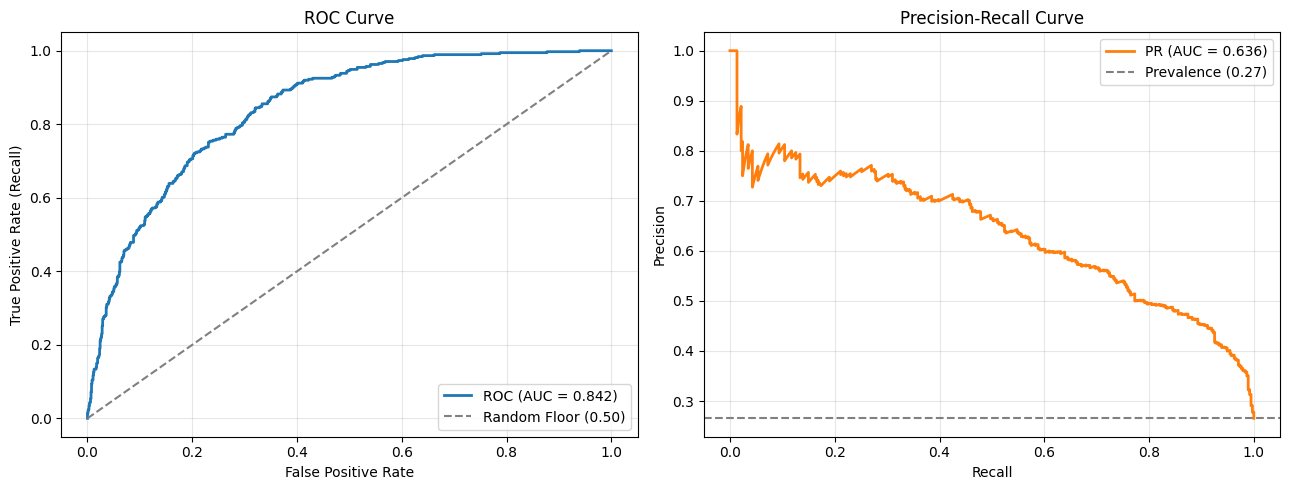

In [13]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba_v1)
precisions, recalls, _ = precision_recall_curve(y_test, y_proba_v1)
pr_auc = auc(recalls, precisions)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
ax1.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"ROC (AUC = {roc_auc_score(y_test, y_proba_v1):.3f})")
ax1.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Floor (0.50)")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate (Recall)")
ax1.set_title("ROC Curve")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="lower right")

# Precision-Recall Curve
baseline_rate = y_test.mean()
ax2.plot(recalls, precisions, color="#ff7f0e", lw=2, label=f"PR (AUC = {pr_auc:.3f})")
ax2.axhline(baseline_rate, color="gray", linestyle="--", label=f"Prevalence ({baseline_rate:.2f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Cost-Sensitive Threshold Optimization
Optimize decision threshold $\tau$ against the asymmetric business cost matrix ($FN = \$500$, $FP = \$50$) to minimize operational financial loss.

Optimal Threshold (tau*) : 0.07
Total Cost at tau*       : $34,900.00
Total Cost at default 0.5: $95,150.00
Projected Cost Savings   : $60,250.00


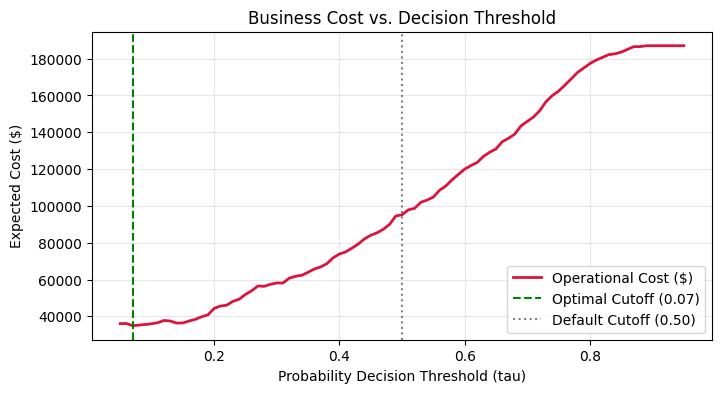

In [14]:
# Cost weights
COST_FN = 500.0  # Missed churner (Lost Customer Lifetime Value)
COST_FP = 50.0   # False alarm (Unnecessary retention incentive)

# Round thresholds to 2 decimal places to avoid floating-point indexing errors
thresholds = np.linspace(0.05, 0.95, 91).round(2)
cost_records = []

for t in thresholds:
    y_pred_t = (y_proba_v1 >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = (fn_t * COST_FN) + (fp_t * COST_FP)
    cost_records.append(total_cost)

cost_series = pd.Series(cost_records, index=thresholds)
optimal_threshold = cost_series.idxmin()
min_cost = cost_series.min()
default_cost = cost_series.loc[0.50]

print(f"Optimal Threshold (tau*) : {optimal_threshold:.2f}")
print(f"Total Cost at tau*       : ${min_cost:,.2f}")
print(f"Total Cost at default 0.5: ${default_cost:,.2f}")
print(f"Projected Cost Savings   : ${default_cost - min_cost:,.2f}")

# Plot Cost Curve
plt.figure(figsize=(8, 4))
plt.plot(thresholds, cost_records, color="crimson", lw=2, label="Operational Cost ($)")
plt.axvline(optimal_threshold, color="green", linestyle="--", label=f"Optimal Cutoff ({optimal_threshold:.2f})")
plt.axvline(0.50, color="gray", linestyle=":", label="Default Cutoff (0.50)")
plt.xlabel("Probability Decision Threshold (tau)")
plt.ylabel("Expected Cost ($)")
plt.title("Business Cost vs. Decision Threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Hyperparameter Exploration: RandomizedSearchCV
Perform a broad exploration across continuous regularization strengths ($C \in [10^{-3}, 10^{2}]$), penalty types ($L_1$ vs $L_2$), and class weighting using 5-fold Stratified Cross-Validation.

In [17]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Parameter space: log-uniform distribution covers orders of magnitude evenly
param_dist = {
    'C': loguniform(1e-3, 1e2),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # liblinear supports both L1 and L2
    'class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_processed, y_train)

print(f"Best CV ROC-AUC : {random_search.best_score_:.4f}")
print("Best Parameters :", random_search.best_params_)

Best CV ROC-AUC : 0.8462
Best Parameters : {'C': np.float64(0.14445251022763064), 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}


## Fine-Grained Optimization: GridSearchCV
Run an exhaustive grid search centered around the best parameter neighborhood identified by `RandomizedSearchCV`.

In [18]:
from sklearn.model_selection import GridSearchCV

# Extract parameters from random search winner
c_center = random_search.best_params_['C']
penalty_winner = random_search.best_params_['penalty']
weight_winner = random_search.best_params_['class_weight']

# Build a focused grid around the winning region
param_grid = {
    'C': np.round([c_center * 0.25, c_center * 0.5, c_center, c_center * 2.0, c_center * 4.0], 4),
    'penalty': [penalty_winner],
    'solver': ['liblinear'],
    'class_weight': [weight_winner]
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

# Assign the winning estimator
best_log_reg = grid_search.best_estimator_

print(f"Refined Best CV ROC-AUC : {grid_search.best_score_:.4f}")
print("Final Hyperparameters   :", grid_search.best_params_)

Refined Best CV ROC-AUC : 0.8462
Final Hyperparameters   : {'C': np.float64(0.1445), 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}


## Model Interpretability: Feature Coefficients & Odds Ratios
Extract weights ($\mathbf{w}$) from the tuned $L_1$ estimator and compute Odds Ratios ($e^w$) to identify top risk drivers, protective retention factors, and zeroed-out features.

In [19]:
# Extract weights and compute Odds Ratios
coefficients = best_log_reg.coef_[0]
odds_ratios = np.exp(coefficients)

# Compile into interpretability table
interpretability_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient (w)": coefficients,
    "Odds_Ratio": odds_ratios
})

# Clean scikit-learn prefix tags
interpretability_df["Feature"] = (
    interpretability_df["Feature"]
    .str.replace("num__", "")
    .str.replace("cat__", "")
)

interpretability_df = interpretability_df.sort_values(by="Coefficient (w)", ascending=False).reset_index(drop=True)

print("=== Top 5 Risk Factors (Increase Churn Odds) ===")
print(interpretability_df.head(5).to_string(index=False))

print("\n=== Top 5 Retention Anchors (Decrease Churn Odds) ===")
print(interpretability_df.tail(5).to_string(index=False))

# Identify features eliminated by L1 penalty
zeroed_out = interpretability_df[interpretability_df["Coefficient (w)"] == 0.0]
print(f"\nFeatures eliminated by L1 penalty (weight = 0.0): {len(zeroed_out)} of {len(feature_names)}")

=== Top 5 Risk Factors (Increase Churn Odds) ===
                       Feature  Coefficient (w)  Odds_Ratio
                MonthlyCharges         0.912585    2.490753
PaymentMethod_Electronic check         0.331010    1.392373
          PaperlessBilling_Yes         0.325562    1.384808
             MultipleLines_Yes         0.134547    1.144019
   InternetService_Fiber optic         0.126929    1.135337

=== Top 5 Retention Anchors (Decrease Churn Odds) ===
           Feature  Coefficient (w)  Odds_Ratio
OnlineSecurity_Yes        -0.512870    0.598775
 Contract_One year        -0.670000    0.511708
            tenure        -0.782628    0.457203
  PhoneService_Yes        -1.024689    0.358908
 Contract_Two year        -1.345541    0.260399

Features eliminated by L1 penalty (weight = 0.0): 15 of 35


## Systematic Error Analysis
Isolate and profile prediction failures (False Positives vs. False Negatives) on the holdout test set to diagnose systematic model blind spots.

In [20]:
# Predict on test set using the tuned estimator
y_pred_tuned = best_log_reg.predict(X_test_processed)
y_proba_tuned = best_log_reg.predict_proba(X_test_processed)[:, 1]

# Build diagnostic DataFrame on raw test features
error_df = X_test.copy()
error_df["True_Churn"] = y_test.values
error_df["Predicted_Churn"] = y_pred_tuned
error_df["Predicted_Risk"] = y_proba_tuned.round(4)

# Flag prediction error types
error_df["Error_Category"] = "Correct"
error_df.loc[(error_df["True_Churn"] == 1) & (error_df["Predicted_Churn"] == 0), "Error_Category"] = "False Negative (Missed Churn)"
error_df.loc[(error_df["True_Churn"] == 0) & (error_df["Predicted_Churn"] == 1), "Error_Category"] = "False Positive (False Alarm)"

print("=== Prediction Outcome Breakdown ===")
print(error_df["Error_Category"].value_counts())

# Inspect characteristics of False Negatives (Missed Churners) vs True Positives (Caught Churners)
fn_mask = error_df["Error_Category"] == "False Negative (Missed Churn)"
tp_mask = (error_df["True_Churn"] == 1) & (error_df["Predicted_Churn"] == 1)

print("\n=== Blind Spot Profile: Missed Churners (FN) vs Caught Churners (TP) ===")
print(f"Median Tenure - Missed (FN) : {error_df.loc[fn_mask, 'tenure'].median():.1f} months")
print(f"Median Tenure - Caught (TP) : {error_df.loc[tp_mask, 'tenure'].median():.1f} months")
print(f"Median Monthly Charges      : ${error_df.loc[fn_mask, 'MonthlyCharges'].median():.2f} (FN) vs ${error_df.loc[tp_mask, 'MonthlyCharges'].median():.2f} (TP)")

print("\nContract Breakdown in Missed Churners (FN):")
print(error_df.loc[fn_mask, "Contract"].value_counts(normalize=True).round(3))

=== Prediction Outcome Breakdown ===
Error_Category
Correct                          1126
False Negative (Missed Churn)     184
False Positive (False Alarm)       99
Name: count, dtype: int64

=== Blind Spot Profile: Missed Churners (FN) vs Caught Churners (TP) ===
Median Tenure - Missed (FN) : 18.0 months
Median Tenure - Caught (TP) : 4.0 months
Median Monthly Charges      : $66.38 (FN) vs $79.88 (TP)

Contract Breakdown in Missed Churners (FN):
Contract
Month-to-month    0.761
One year          0.190
Two year          0.049
Name: proportion, dtype: float64


## Candidate Model Benchmark Summary
Compare performance metrics across the baseline dummy model, untuned default estimator, and final tuned $L_1$ model on the holdout test set.

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred, y_proba):
    return {
        "Accuracy": float((y_true == y_pred).mean()),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1 Score": float(f1_score(y_true, y_pred, zero_division=0)),
        "ROC-AUC": float(roc_auc_score(y_true, y_proba)),
        "Log Loss": float(log_loss(y_true, y_proba))
    }

comparison_table = pd.DataFrame([
    {"Model": "1. Baseline (Dummy)", **evaluate_model(y_test, y_pred_dummy, y_proba_dummy)},
    {"Model": "2. Default Logistic Regression", **evaluate_model(y_test, y_pred_v1, y_proba_v1)},
    {"Model": "3. Tuned L1 Logistic Regression", **evaluate_model(y_test, y_pred_tuned, y_proba_tuned)}
]).set_index("Model")

comparison_table.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Log Loss
Model,,,,,,
1. Baseline (Dummy),0.7346,0.0000,0.0000,0.0000,0.5000,9.5673
2. Default Logistic Regression,0.7991,0.6532,0.5187,0.5782,0.8423,0.4195
3. Tuned L1 Logistic Regression,0.7991,0.6574,0.5080,0.5732,0.8430,0.4188


## Production Pipeline Assembly & Artifact Serialization
Bundle the fitted `preprocessor` and the tuned estimator into an atomic scikit-learn `Pipeline` and persist it to disk via `joblib`.

In [22]:
import joblib
from sklearn.pipeline import Pipeline

# Assemble end-to-end production pipeline
production_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", best_log_reg)
])

# Ensure models directory exists and serialize artifact
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)
artifact_path = models_dir / "telco_churn_pipeline.joblib"

joblib.dump(production_pipeline, artifact_path)
print(f"Production pipeline successfully exported to: {artifact_path}")

Production pipeline successfully exported to: D:\AI-ML\NOTES\logistic-regression\telco-churn-guardian\models\telco_churn_pipeline.joblib


## Real-Time Inference Simulation
Load the serialized pipeline artifact from disk and score a raw, un-preprocessed customer payload at our cost-optimized decision threshold.

In [23]:
# Load the serialized pipeline artifact from disk
deployed_pipeline = joblib.load(artifact_path)

# Simulated raw customer JSON payload (identical to what Streamlit will submit)
raw_customer_payload = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 70.35,
    "TotalCharges": 139.05
}

# Transform to DataFrame and apply domain feature transformations
payload_df = pd.DataFrame([raw_customer_payload])
payload_featured, _ = engineer_features(payload_df)

# Score customer at the cost-optimized threshold
OPERATIONAL_THRESHOLD = float(optimal_threshold)
predicted_churn_risk = deployed_pipeline.predict_proba(payload_featured)[0, 1]
churn_flag = int(predicted_churn_risk >= OPERATIONAL_THRESHOLD)

print("=== Real-Time Inference Output ===")
print(f"Customer Churn Probability : {predicted_churn_risk:.2%}")
print(f"Operational Decision Cutoff : {OPERATIONAL_THRESHOLD:.2%}")
print(f"Actionable Decision         : {'FLAGGED: High Risk -> Dispatch Retention Offer' if churn_flag == 1 else 'STANDARD: Low Risk -> No Action'}")

=== Real-Time Inference Output ===
Customer Churn Probability : 70.28%
Operational Decision Cutoff : 7.00%
Actionable Decision         : FLAGGED: High Risk -> Dispatch Retention Offer
